<a href="https://colab.research.google.com/github/zmhibner-gif/ml_internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/zmhibner-gif/ml_internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [ ]:
from google.colab import userdata
import duckdb

HF_TOKEN = userdata.get("HF_TOKEN")

con = duckdb.connect()

safe_token = HF_TOKEN.replace("'", "''")

con.execute(
    f"CREATE OR REPLACE SECRET hf_secret "
    f"(TYPE huggingface, TOKEN '{safe_token}')"
)

# Main warehouse path
WAREHOUSE = "hf://datasets/FlyRank/internship-warehouse"

print("Hugging Face connection ready.")

Hugging Face connection ready.


## 1. Question

**Research question:**
Can search-performance data be used to group pages into actionable content archetypes?

**Decision supported:**
The analysis supports deciding which pages should be protected, improved, rewritten, merged, pruned, or monitored based on their search-performance pattern.

## 2. Data

The analysis uses the FlyRank ML Internship warehouse hosted on Hugging Face. I use the fact_content_daily_performance table for March 2026.

The unit of analysis is one page aggregated over the month. I keep five search-performance features: impressions, CTR, average search position, days with impressions, and days with clicks.

Rows without Google Search Console data are excluded, as are pages with zero total impressions. Client and content hash IDs are kept only to identify pages and are not used as model features.

No client names, domains, URLs, private queries, credentials, future-month data, or label-derived fields are included.

In [ ]:
# March slice data set set up
MONTH = "2026-03"

WAREHOUSE = "hf://datasets/FlyRank/internship-warehouse"
FACT = f"{WAREHOUSE}/fact_content_daily_performance"
MAR = f"read_parquet('{FACT}/month={MONTH}/*.parquet')"

feature_df = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(gsc_impressions) AS impressions,

        100.0 * SUM(gsc_clicks)
        / NULLIF(SUM(gsc_impressions), 0) AS ctr,

        SUM(gsc_sum_position)
        / NULLIF(SUM(gsc_impressions), 0) AS avg_position,

        COUNT(*) FILTER (
            WHERE gsc_impressions > 0
        ) AS days_with_impressions,

        COUNT(*) FILTER (
            WHERE gsc_clicks > 0
        ) AS days_with_clicks

    FROM {MAR}
    WHERE gsc_data_available IS TRUE

    GROUP BY
        client_hash_id,
        content_hash_id

    HAVING SUM(gsc_impressions) > 0
""").df()

print(feature_df.shape[0], "pages,", feature_df.shape[1], "columns")
feature_df.head(10)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

176738 pages, 7 columns


,client_hash_id,content_hash_id,impressions,ctr,avg_position,days_with_impressions,days_with_clicks
0,client_62f4a7e64f5e0096,content_39d7361b4945d504,77.0,0.000000,4.311688,24,0
1,client_62f4a7e64f5e0096,content_c03ecafd4c999f15,10849.0,0.202784,8.049866,31,14
2,client_62f4a7e64f5e0096,content_e689bc511192751a,61.0,0.000000,5.885246,27,0
3,client_62f4a7e64f5e0096,content_7dbc094b799e05a4,705.0,0.141844,5.863830,31,1
4,client_62f4a7e64f5e0096,content_40b10da45f4c1cb5,50.0,0.000000,14.360000,21,0
5,client_62f4a7e64f5e0096,content_df22bda1218f13ff,2099.0,0.047642,2.632206,31,1
6,client_62f4a7e64f5e0096,content_aa184c1b4ea518e5,288.0,0.000000,10.489583,30,0
7,client_62f4a7e64f5e0096,content_b4de71c8ef5c4791,3535.0,0.707214,3.151344,31,14
8,client_62f4a7e64f5e0096,content_d7568011c4325a33,1558.0,0.192555,5.247112,31,3
9,client_62f4a7e64f5e0096,content_e847a4dcc8af3742,2021.0,0.000000,7.853538,31,0


## 3. Methodology

This project uses **K-Means clustering** to group pages with similar search-performance patterns. K-Means fits the project because the goal is to discover recurring performance archetypes rather than predict an existing label.

**Features**

The model uses the same five features defined in the Week 3 data contract:

* impressions
* CTR
* average search position
* days with impressions
* days with clicks

Client and content IDs are excluded from the model and are used only to identify pages.

**Label definition**

There is no predefined target label because this is an unsupervised clustering task. Cluster membership is produced by the model and is treated as a descriptive grouping rather than a true label.

**Baseline**

The Week 4 rule-based baseline is reused. It identifies pages with at least 500 impressions whose CTR is below the average CTR for their search-position bucket. Pages are ranked by the estimated missed-click opportunity:

baseline score = impressions × CTR gap

The baseline provides a simple, transparent comparison before using clustering to identify a wider range of performance patterns.

**Validation design**

The number of clusters will be selected by comparing clustering quality across several values of K and then checking whether the resulting groups are understandable and useful for content decisions. Cluster profiles will also be inspected rather than relying on one metric alone.

**Leakage checks**

All clustering features come from the March 2026 development window. No future-month data, product flags, label-derived fields, client IDs, or content IDs are used as model features.


In [ ]:
# Select the five features defined in the Week 3 data contract.
features = [
    "impressions",
    "ctr",
    "avg_position",
    "days_with_impressions",
    "days_with_clicks"
]

X = feature_df[features].copy()

# Check the feature values before deciding how to prepare them for clustering.
print("Pages:", X.shape[0])
X.describe()

Pages: 176738


,impressions,ctr,avg_position,days_with_impressions,days_with_clicks
count,176738.000000,176738.000000,176738.000000,176738.000000,176738.000000
mean,1587.986675,0.459397,15.992270,20.431718,2.364975
std,5431.337724,3.775992,18.097575,11.480153,5.238867
min,1.000000,0.000000,0.000000,1.000000,0.000000
25%,20.000000,0.000000,4.917879,9.000000,0.000000
50%,173.000000,0.000000,8.177966,26.000000,0.000000
75%,1039.000000,0.215796,20.254025,31.000000,2.000000
max,617124.000000,100.000000,309.000000,31.000000,31.000000


**Feature preparation**

Impressions, CTR, and average position are strongly skewed, so they are log-transformed to reduce the influence of extreme values. All five features are then standardized before clustering so that differences in scale do not cause one feature to dominate the K-Means distance calculation.


In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Make a copy of the feature data before preprocessing.
X_model = X.copy()

# Reduce the effect of very large values in the most skewed features.
for column in ["impressions", "ctr", "avg_position"]:
    X_model[column] = np.log1p(X_model[column])

# Standardize all five features so they are on a comparable scale.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_model)

print("Prepared data shape:", X_scaled.shape)

Prepared data shape: (176738, 5)


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

# Split by client so pages from the same client do not appear
# in both the training and test sets.
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, groups=feature_df["client_hash_id"])
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

print("Training pages:", len(X_train))
print("Test pages:", len(X_test))

Training pages: 138310
Test pages: 38428


In [ ]:
# Apply the same log transformation to training and test data.
X_train_model = X_train.copy()
X_test_model = X_test.copy()

for column in ["impressions", "ctr", "avg_position"]:
    X_train_model[column] = np.log1p(X_train_model[column])
    X_test_model[column] = np.log1p(X_test_model[column])

# Fit the scaler only on the training data.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_model)
X_test_scaled = scaler.transform(X_test_model)

**Choosing the number of clusters**

I compare K-Means solutions from 2 to 6 clusters using only the training data. I use inertia to look for diminishing improvements as more clusters are added, and silhouette score to measure how clearly the groups are separated. The silhouette score is calculated on a sample of 10,000 training pages to keep the evaluation practical.



In [ ]:

import pandas as pd

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

results = []

# Compare possible cluster counts using only the training data.
for k in range(2, 7):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_train_scaled)

    # Calculate silhouette score on a sample to keep it practical.
    silhouette = silhouette_score(
        X_train_scaled,
        labels,
        sample_size=10000,
        random_state=42
    )

    results.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette_score": silhouette
    })

k_results = pd.DataFrame(results)
k_results

,k,inertia,silhouette_score
0,2,462800.367898,0.371228
1,3,352822.487595,0.384691
2,4,267060.431430,0.407227
3,5,211243.481428,0.388652
4,6,178191.908817,0.357251


**Selected number of clusters: 4**

K = 4 produced the highest silhouette score (0.404) among the tested solutions. Inertia also continued to decrease, but the improvement became less useful once additional clusters reduced the silhouette score. Therefore, four clusters were selected as the best balance between separation and simplicity.



## 4. Results (vs baseline)

The final K-Means model uses four clusters and is fitted on the training clients only. Results are evaluated on the held-out test clients.

For comparison, the Week 4 baseline is applied to the same test pages. The baseline separates pages into two groups: pages flagged for low CTR relative to position and pages not flagged.

Because this is an unsupervised task with no true class label, accuracy and precision are not appropriate. I compare the two segmentations using silhouette score, which measures how well separated the resulting groups are in the same five-feature space.

In [ ]:
# Fit the final K-Means model on the training data.
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans.fit(X_train_scaled)

# Assign a cluster to each held-out test page.
test_clusters = kmeans.predict(X_test_scaled)

test_results = feature_df.iloc[test_idx].copy()
test_results["cluster"] = test_clusters

print("Test pages:", len(test_results))

Test pages: 38428


In [ ]:
# Create the same search-position buckets used in the Week 4 baseline.
position_bins = [0, 3, 5, 10, 20, 50, float("inf")]
position_labels = ["1-3", "4-5", "6-10", "11-20", "21-50", "51+"]

train_baseline = feature_df.iloc[train_idx].copy()
test_baseline = test_results.copy()

train_baseline["position_bucket"] = pd.cut(
    train_baseline["avg_position"],
    bins=position_bins,
    labels=position_labels,
    include_lowest=True
)

test_baseline["position_bucket"] = pd.cut(
    test_baseline["avg_position"],
    bins=position_bins,
    labels=position_labels,
    include_lowest=True
)

# Calculate expected CTR from the training pages only.
expected_ctr = (
    train_baseline.groupby("position_bucket", observed=True)["ctr"]
    .mean()
    .rename("expected_ctr")
)

test_baseline = test_baseline.join(
    expected_ctr,
    on="position_bucket"
)

# Apply the same Week 4 rule.
test_baseline["ctr_gap"] = (
    test_baseline["expected_ctr"] - test_baseline["ctr"]
).clip(lower=0)

test_baseline["baseline_flag"] = (
    (test_baseline["impressions"] >= 500) &
    (test_baseline["ctr_gap"] > 0)
).astype(int)

test_baseline["baseline_flag"].value_counts()

,count
baseline_flag,
0,23490
1,14938


In [ ]:
# Measure separation on the same held-out pages.
kmeans_silhouette = silhouette_score(
    X_test_scaled,
    test_clusters
)

baseline_silhouette = silhouette_score(
    X_test_scaled,
    test_baseline["baseline_flag"]
)

comparison = pd.DataFrame({
    "method": ["Week 4 baseline", "K-Means"],
    "groups": [2, 4],
    "test_silhouette": [
        baseline_silhouette,
        kmeans_silhouette
    ]
})

comparison.round(3)

,method,groups,test_silhouette
0,Week 4 baseline,2,0.215
1,K-Means,4,0.377


 K-Means achieved a test silhouette score of 0.377, compared with 0.215 for the Week 4 baseline on the same held-out pages. This suggests that the four-cluster model separates search-performance patterns more clearly than the simple low-CTR rule.

The baseline still serves a different purpose: it identifies one specific CTR opportunity, while clustering is designed to describe a wider range of page-performance patterns. The silhouette comparison therefore measures group separation, not the business impact of the recommendations.


In [ ]:
# Count how many held-out pages belong to each cluster.
cluster_counts = (
    test_results["cluster"]
    .value_counts()
    .sort_index()
    .rename("n")
    .reset_index()
)

cluster_counts

,cluster,n
0,0,5383
1,1,7751
2,2,506
3,3,24788


In [ ]:
# Profile each cluster using the original, easy-to-interpret feature values.
cluster_profile = (
    test_results.groupby("cluster")
    .agg(
        n=("content_hash_id", "size"),
        median_impressions=("impressions", "median"),
        median_ctr=("ctr", "median"),
        median_position=("avg_position", "median"),
        median_days_with_impressions=("days_with_impressions", "median"),
        median_days_with_clicks=("days_with_clicks", "median")
    )
    .reset_index()
)

cluster_profile

,cluster,n,median_impressions,median_ctr,median_position,median_days_with_impressions,median_days_with_clicks
0,0,5383,6102.0,0.378629,3.706493,31.0,14.0
1,1,7751,12.0,0.000000,8.809524,5.0,0.0
2,2,506,25.0,4.858379,7.892857,9.0,1.0
3,3,24788,411.0,0.000000,9.183421,31.0,0.0


The four clusters show distinct search-performance patterns:

* **Cluster 0 - Low-visibility pages:** very few impressions, limited days with visibility, and typically no clicks.
* **Cluster 1 - Persistent visibility, weak engagement:** pages appear throughout the month and receive more impressions, but the typical page still receives no clicks.
* **Cluster 2 - Low-volume, high-CTR pages:** a small group with relatively few impressions but much higher CTR and some click activity.
* **Cluster 3 - High-visibility, active pages:** pages receive thousands of impressions, rank relatively well, and receive clicks on many days.

Cluster 1 is the largest group, while Cluster 2 is much smaller than the others. This suggests that the model separates a rare high-CTR pattern from the more common low-click and high-visibility patterns.


In [ ]:
# Add the baseline result to the clustered test pages.
test_results["baseline_flag"] = test_baseline["baseline_flag"].values

# Compare baseline flags across the four clusters.
baseline_by_cluster = pd.crosstab(
    test_results["cluster"],
    test_results["baseline_flag"],
    margins=True
)

baseline_by_cluster

baseline_flag,0,1,All
cluster,,,
0,943,4440,5383
1,7718,33,7751
2,506,0,506
3,14323,10465,24788
All,23490,14938,38428


**Baseline overlap with clusters**

The Week 4 baseline does not treat all four clusters equally. It flags almost none of the low-visibility pages in Cluster 0 and none of the high-CTR pages in Cluster 2. Most baseline flags fall within Clusters 1 and 3, where pages have enough visibility for a CTR gap to become meaningful.

This shows the difference between the two approaches. The baseline identifies one specific opportunity - visible pages with below-expected CTR - while K-Means separates several different performance archetypes, including page types that the baseline does not target.

## 5. Limitations

This analysis identifies patterns in search-performance data, but it does not prove why a page performs in a certain way or whether a specific content change would improve performance.

The clusters are descriptive groups, not true labels. Pages within the same cluster may still differ in content type, search intent, SERP features, or other factors that are not included in the model.

The analysis uses March 2026 data, so the results may not fully represent seasonal changes or longer-term performance patterns. The model was also built only from the five selected search-performance features, which means other useful signals may be missing.

The recommendations should therefore be treated as decision-support for content review, not as automatic instructions or causal conclusions.

## 6. Ranked recommendations

The four clusters are translated into different content actions based on their observed search-performance patterns.

1. **Cluster 1 - Improve CTR:** These pages have persistent search visibility but typically receive no clicks. They should be reviewed first for search intent, titles, descriptions, and content relevance.

2. **Cluster 3 - Protect and selectively optimize:** These are high-visibility pages with regular click activity. They are valuable pages that should generally be protected, although pages also flagged by the CTR baseline may still benefit from careful optimization.

3. **Cluster 2 - Improve visibility:** These pages have relatively strong CTR but low impression volume. Their content appears able to attract clicks when shown, so the priority is improving visibility rather than rewriting for CTR.

4. **Cluster 0 - Monitor:** These pages have very little visibility and almost no click activity. One month of low volume is not enough evidence to justify merging or pruning them, so they should be monitored before stronger action is taken.

These recommendations are decision-support rather than automatic instructions. An editor should review page context before making changes.


In [ ]:
# Map each performance archetype to a recommended action.
action_map = {
    0: "MONITOR",
    1: "IMPROVE_CTR",
    2: "IMPROVE_VISIBILITY",
    3: "PROTECT"
}

test_results["action"] = test_results["cluster"].map(action_map)

In [ ]:
# Use the missed-click score for pages that need CTR improvement.
test_results["baseline_score"] = (
    test_baseline["impressions"]
    * test_baseline["ctr_gap"]
    / 100
).values

# Start with impressions as the simple priority measure.
test_results["priority_score"] = test_results["impressions"]

# For CTR improvement pages, use the missed-click opportunity score.
test_results.loc[
    test_results["action"] == "IMPROVE_CTR",
    "priority_score"
] = test_results["baseline_score"]

# Rank pages separately within each recommended action.
test_results["action_rank"] = (
    test_results.groupby("action")["priority_score"]
    .rank(method="first", ascending=False)
    .astype(int)
)

# Show the top 5 pages for each action.
recommendations = (
    test_results[test_results["action_rank"] <= 5]
    .sort_values(["action", "action_rank"])
)

recommendations[
    [
        "action",
        "action_rank",
        "content_hash_id",
        "cluster",
        "impressions",
        "ctr",
        "avg_position",
        "priority_score"
    ]
]

,action,action_rank,content_hash_id,cluster,impressions,ctr,avg_position,priority_score
82578,IMPROVE_CTR,1,content_243ca68e29976cae,1,950.0,0.210526,2.625263,10.874267
82326,IMPROVE_CTR,2,content_d146407268afe4d3,1,761.0,0.000000,0.186597,10.312965
167148,IMPROVE_CTR,3,content_4a3aa2d2aeb367d1,1,891.0,0.224467,1.562290,10.074707
82489,IMPROVE_CTR,4,content_5adc6748203100a4,1,830.0,0.240964,1.755422,9.248044
170769,IMPROVE_CTR,5,content_dfc2900323c36927,1,661.0,0.000000,2.167927,8.957779
159628,IMPROVE_VISIBILITY,1,content_f93cf81d5564765d,2,2642.0,2.838759,1.629069,2642.000000
75747,IMPROVE_VISIBILITY,2,content_76561de7093323de,2,1075.0,3.441860,1.985116,1075.000000
143809,IMPROVE_VISIBILITY,3,content_66547baf66929a66,2,1028.0,3.501946,7.036965,1028.000000
164029,IMPROVE_VISIBILITY,4,content_eef81e0747996284,2,807.0,4.213135,3.193309,807.000000
75309,IMPROVE_VISIBILITY,5,content_80fc3f2d493c06db,2,490.0,2.857143,2.393878,490.000000



The final recommendation output ranks pages separately within each action group:

* **IMPROVE_CTR:** pages with strong visibility but unusually weak CTR are ranked by estimated missed-click opportunity.
* **IMPROVE_VISIBILITY:** pages with relatively strong CTR but lower overall visibility are prioritized for opportunities to gain more impressions.
* **MONITOR:** lower-activity pages are kept under observation rather than changed immediately.
* **PROTECT:** the highest-visibility, actively clicked pages are prioritized for preservation and cautious optimization.

Ranking is done within each action because the meaning of priority differs between archetypes. A high-priority `PROTECT` page is not directly comparable with a high-priority `IMPROVE_CTR` page.


## 7. Artifacts the paper embeds

The final paper uses three main result artifacts:

Model vs baseline comparison - compares held-out silhouette scores for K-Means and the Week 4 baseline.
Cluster sizes - shows how many pages belong to each discovered performance archetype.
Cluster profile table - summarizes the typical impressions, CTR, position, and activity of each cluster.

These artifacts are used to show both the quantitative model comparison and the practical meaning of the resulting clusters.

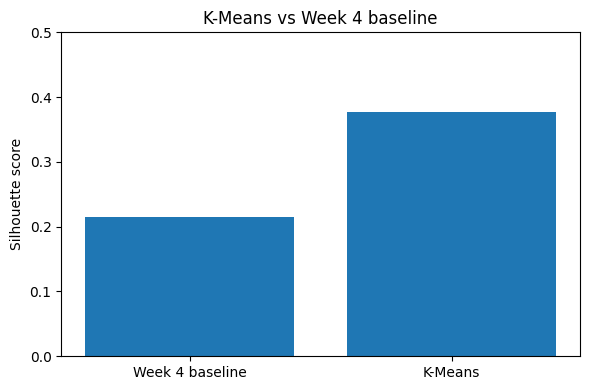

In [ ]:
import matplotlib.pyplot as plt
import os

# Create the output folder if it does not already exist.
os.makedirs("work/outputs", exist_ok=True)

# Compare group separation on the held-out test pages.
plt.figure(figsize=(6, 4))

plt.bar(
    comparison["method"],
    comparison["test_silhouette"]
)

plt.ylabel("Silhouette score")
plt.title("K-Means vs Week 4 baseline")
plt.ylim(0, 0.5)

plt.tight_layout()
plt.savefig(
    "work/outputs/model_vs_baseline.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

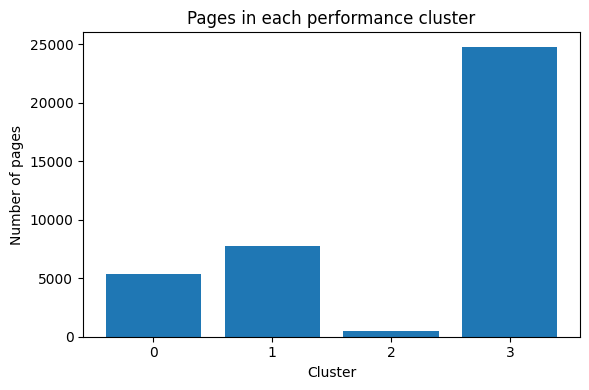

In [ ]:
# Show the number of held-out pages in each cluster.
plt.figure(figsize=(6, 4))

plt.bar(
    cluster_counts["cluster"].astype(str),
    cluster_counts["n"]
)

plt.xlabel("Cluster")
plt.ylabel("Number of pages")
plt.title("Pages in each performance cluster")

plt.tight_layout()
plt.savefig(
    "work/outputs/cluster_sizes.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Create a clearer cluster-profile table for the final paper.
paper_cluster_profile = cluster_profile.copy()

paper_cluster_profile["archetype"] = paper_cluster_profile["cluster"].map({
    0: "Low visibility",
    1: "Visible, weak engagement",
    2: "Low volume, high CTR",
    3: "High visibility, active"
})

paper_cluster_profile = paper_cluster_profile[
    [
        "cluster",
        "archetype",
        "n",
        "median_impressions",
        "median_ctr",
        "median_position",
        "median_days_with_impressions",
        "median_days_with_clicks"
    ]
]

paper_cluster_profile

,cluster,archetype,n,median_impressions,median_ctr,median_position,median_days_with_impressions,median_days_with_clicks
0,0,Low visibility,5383,6102.0,0.378629,3.706493,31.0,14.0
1,1,"Visible, weak engagement",7751,12.0,0.000000,8.809524,5.0,0.0
2,2,"Low volume, high CTR",506,25.0,4.858379,7.892857,9.0,1.0
3,3,"High visibility, active",24788,411.0,0.000000,9.183421,31.0,0.0


## **ML-12**

## 5 minute demo outline

**1. Problem**
Pages can underperform in search for different reasons, so one rule may not be enough to decide what action to take.

**2. Data**
I used March 2026 FlyRank search-performance data and five page-level features: impressions, CTR, average position, days with impressions, and days with clicks.

**3. Baseline**
I first built a simple rule that flags visible pages with lower-than-expected CTR for their search position.

**4. Model**
I used K-Means clustering and selected four clusters based on silhouette score and interpretability. On held-out test pages, K-Means achieved a silhouette score of 0.377 compared with 0.215 for the baseline grouping.

**5. Result and action**
The model found four useful archetypes: low visibility, visible but weak engagement, low volume with high CTR, and high visibility with active clicks. These were mapped to actions such as monitor, improve CTR, improve visibility, and protect.


## Social-post cut
I built a search-performance clustering project using real FlyRank internship data.

The goal was to group pages into actionable performance archetypes instead of treating all underperforming pages the same way. Using K-Means on five search signals, I identified four distinct page patterns and mapped them to actions such as improve CTR, improve visibility, monitor, and protect.

On held-out test pages, the clustering approach produced more clearly separated groups than my simple rule-based baseline.


## Employer-facing summary

I built an end-to-end unsupervised ML analysis using real search-performance data, from data preparation and leakage checks to baseline design, clustering, validation, and ranked recommendations. The final K-Means model identified four distinct performance archetypes and showed stronger held-out group separation than the rule-based baseline. I translated the model output into practical content actions, demonstrating how ML results can support real editorial decisions rather than stopping at model metrics.


## **Reproductibility**

In [ ]:
import json
import os

# Save the main evaluation settings and results so the holdout test is reproducible.
metrics = {
    "random_seed": 42,
    "split": "GroupShuffleSplit by client",
    "test_size": 0.2,
    "train_pages": len(train_idx),
    "test_pages": len(test_idx),
    "selected_k": 4,
    "train_silhouette_k4": round(
        float(k_results.loc[k_results["k"] == 4, "silhouette_score"].iloc[0]),
        3
    ),
    "test_silhouette_kmeans": round(float(kmeans_silhouette), 3),
    "test_silhouette_baseline": round(float(baseline_silhouette), 3),
    "baseline_flagged_test_pages": int(test_baseline["baseline_flag"].sum())
}

os.makedirs("work/outputs", exist_ok=True)

with open("work/outputs/capstone_metrics.json", "w") as file:
    json.dump(metrics, file, indent=2)

print(metrics)

{'random_seed': 42, 'split': 'GroupShuffleSplit by client', 'test_size': 0.2, 'train_pages': 138310, 'test_pages': 38428, 'selected_k': 4, 'train_silhouette_k4': 0.407, 'test_silhouette_kmeans': 0.377, 'test_silhouette_baseline': 0.215, 'baseline_flagged_test_pages': 14938}


In [ ]:
import sys
import numpy as np
import pandas as pd
import sklearn
import duckdb

# Record the main package versions used for the analysis.
print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("DuckDB:", duckdb.__version__)

Python: 3.13.15
NumPy: 2.1.3
pandas: 2.2.3
scikit-learn: 1.6.1
DuckDB: 1.3.2


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
